# PaliGemma2 Fine-tuning — Lokálny dataset (person/weapon detection)

Notebook upravený pre server s **32-core CPU, 128GB RAM, NVIDIA L40S 48GB**.

Dataset formát: JSONL s lokálnymi obrázkami.

## 1. Inštalácia závislostí

In [1]:
!pip install -q -U datasets bitsandbytes peft transformers accelerate Pillow

In [1]:
from roboflow import Roboflow
from dotenv import load_dotenv
import os

load_dotenv()

ROBOFLOW_API_KEY = os.getenv("RF_TOKEN")
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("aienv").project("person-weapon-dataset-combined")
version = project.version(1)
dataset = version.download("paligemma")


## 2. Konfigurácia — uprav tu svoje cesty

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# ==================== KONFIGURÁCIA ====================
DATASET_PATH  = "Person-Weapon-Dataset-Combined-1/dataset/_annotations.train.jsonl"
IMAGE_FOLDER  = "Person-Weapon-Dataset-Combined-1/dataset/"
import os
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"
MODEL_ID      = "google/paligemma2-3b-pt-224"

OUTPUT_DIR    = "paligemma2_weapon_finetune7"
HF_REPO_ID    = None   # napr. "tvoj-username/paligemma2-weapon" alebo None ak nechceš pushnúť

# Tréningové hyperparametre
BATCH_SIZE = 4
GRAD_ACCUM = 8
LEARNING_RATE = 2e-5  # Nižší learning rate je pre PaliGemmu bezpečnejší
NUM_EPOCHS = 2
USE_LORA      = True   # True = LoRA (odporúčané), False = full fine-tune text dekodera
# =======================================================

## 3. Načítanie a príprava datasetu

In [10]:
import json
import os
import re
import random
from pathlib import Path
from PIL import Image

# ── Nastavenia ──────────────────────────────────────────────────────────────
BASE_DIR      = "/src/train/Person-Weapon-Dataset-Combined-1/dataset"  # koreňový priečinok datasetu

SPLIT_MODE    = "random"              # "random" | "always_split" | "never_split"
SPLIT_PROB    = 0.5                   # pri "random": pravdepodobnosť rozdelenia (0.0–1.0)
RANDOM_SEED   = 42                    # None = iné poradie každý run
# ────────────────────────────────────────────────────────────────────────────

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)

_loc_pattern = re.compile(r'(<loc\d+><loc\d+><loc\d+><loc\d+>)\s+(\w+)')


def _expand_record(img_path: str, prefix: str, suffix: str) -> list[dict]:
    detections = _loc_pattern.findall(suffix)

    requested = []
    if 'person' in prefix.lower():
        requested.append('person')
    if 'weapon' in prefix.lower():
        requested.append('weapon')

    if len(requested) <= 1:
        return [{"image_path": img_path, "prefix": prefix, "suffix": suffix}]

    do_split = {
        "always_split": True,
        "never_split":  False,
        "random":       random.random() < SPLIT_PROB,
    }[SPLIT_MODE]

    if not do_split:
        return [{"image_path": img_path, "prefix": prefix, "suffix": suffix}]

    results = []
    for label_type in requested:
        filtered = [
            f'{bbox} {lbl}'
            for bbox, lbl in detections
            if lbl.lower() == label_type
        ]
        if not filtered:
            continue
        results.append({
            "image_path": img_path,
            "prefix":     f"detect {label_type}",
            "suffix":     " ; ".join(filtered),
        })

    return results if results else [{"image_path": img_path, "prefix": prefix, "suffix": suffix}]


def load_jsonl_dataset(jsonl_path: str, image_folder: str) -> list[dict]:
    records = []
    skipped = 0
    line_num = 0
    image_folder = Path(image_folder)

    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue

            try:
                record = json.loads(line)
            except json.JSONDecodeError as e:
                print(f"  [WARN] Riadok {line_num} preskočený (JSON chyba): {e}")
                skipped += 1
                continue

            image_file = (record.get("image")
                          or record.get("file_name")
                          or record.get("filename"))
            prefix     = (record.get("prefix")
                          or record.get("question")
                          or record.get("prompt")
                          or "")
            suffix     = (record.get("suffix")
                          or record.get("answer")
                          or record.get("label")
                          or "")

            if not image_file:
                print(f"  [WARN] Riadok {line_num}: chýba pole 'image', preskočené")
                skipped += 1
                continue

            img_path = image_folder / image_file
            if not img_path.exists():
                print(f"  [WARN] Riadok {line_num}: obrázok nenájdený: {img_path}")
                skipped += 1
                continue

            records.extend(_expand_record(str(img_path), prefix, suffix))

    print(f"Spracovaných riadkov:  {line_num - skipped}")
    print(f"Preskočených riadkov:  {skipped}")
    print(f"Výsledných záznamov:   {len(records)}")
    print(f"Split mód:             {SPLIT_MODE}"
          + (f" (p={SPLIT_PROB})" if SPLIT_MODE == "random" else ""))
    return records


# ── Spustenie ────────────────────────────────────────────────────────────────
train_records = load_jsonl_dataset(f"{BASE_DIR}/_annotations.train.jsonl", f"{BASE_DIR}")
valid_records = load_jsonl_dataset(f"{BASE_DIR}/_annotations.valid.jsonl", f"{BASE_DIR}")
test_records  = load_jsonl_dataset(f"{BASE_DIR}/_annotations.test.jsonl",  f"{BASE_DIR}")

# Ukážka prvých 3 záznamov z trainu
print("\nUkážka train záznamov:")
for r in train_records[:3]:
    print(json.dumps({k: v for k, v in r.items() if k != "image_path"}, ensure_ascii=False, indent=2))
    print("image_path:", r["image_path"])
    print()

Spracovaných riadkov:  34673
Preskočených riadkov:  0
Výsledných záznamov:   38725
Split mód:             random (p=0.5)
Spracovaných riadkov:  752
Preskočených riadkov:  0
Výsledných záznamov:   766
Split mód:             random (p=0.5)
Spracovaných riadkov:  766
Preskočených riadkov:  0
Výsledných záznamov:   783
Split mód:             random (p=0.5)

Ukážka train záznamov:
{
  "prefix": "detect person ; weapon",
  "suffix": "<loc0365><loc0662><loc0423><loc0693> weapon"
}
image_path: /home/xpekarcik/video-based-action-recognition/djangoweb/src/train/Person-Weapon-Dataset-Combined-1/dataset/SDYMO7GLX6VIPPK8WAHIXVOA2TBH6F_jpg.rf.5b5372f98ff473bc33a8a0dba2dc2806.jpg

{
  "prefix": "detect weapon",
  "suffix": "<loc0290><loc0434><loc0401><loc0485> weapon"
}
image_path: /home/xpekarcik/video-based-action-recognition/djangoweb/src/train/Person-Weapon-Dataset-Combined-1/dataset/aug_m_019520_jpg.rf.1036e3f530f2586f81b57d69835aef27.jpg

{
  "prefix": "detect weapon",
  "suffix": "<loc0435><lo

In [8]:
import random

random.seed(42)
random.shuffle(all_records)

split_idx  = int(len(all_records) * 0.9)
train_data = all_records[:split_idx]
val_data   = all_records[split_idx:]

print(f"Train: {len(train_data)} | Val: {len(val_data)}")

NameError: name 'all_records' is not defined

## 4. Načítanie modelu a processora

In [11]:
import torch
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Použité zariadenie: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

processor = PaliGemmaProcessor.from_pretrained(MODEL_ID)
print("Processor načítaný.")

Processor načítaný.


In [14]:
from peft import get_peft_model, LoraConfig
from transformers import PaliGemmaForConditionalGeneration

lora_config = LoraConfig(
    r=32,                  # Znížené zo 128 - zabráni rozbitiu modelu
    lora_alpha=64,         # Štandardne 2x hodnota ranku
    target_modules=["q_proj", "o_proj", "k_proj", "v_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    task_type="CAUSAL_LM",
)

model = PaliGemmaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map={"": torch.cuda.current_device()},
)
model.gradient_checkpointing_enable()
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

DTYPE = torch.bfloat16

trainable params: 47,505,408 || all params: 3,079,747,824 || trainable%: 1.5425


## 5. Collate funkcia

In [21]:
from PIL import Image

def collate_fn(examples):
    texts = [example["prefix"] for example in examples]
    labels = [example["suffix"] for example in examples]

    # OPRAVA TU: Načítanie obrázkov z cesty, ak ešte nie sú načítané
    images = []
    for example in examples:
        img_path = example["image"]
        try:
            # Ak je to cesta (string), otvoríme ju. Ak je to už Image, necháme tak.
            if isinstance(img_path, str):
                image = Image.open(img_path).convert("RGB")
            else:
                image = img_path.convert("RGB")
            images.append(image)
        except Exception as e:
            print(f"Chyba pri načítaní obrázka {img_path}: {e}")
            # Vytvoríme prázdny čierny obrázok ako fallback, aby nepadol tréning
            images.append(Image.new("RGB", (224, 224), (0, 0, 0)))

    # Spracovanie cez processor
    tokens = processor(
        text=texts,
        images=images,
        suffix=labels,
        return_tensors="pt",
        padding="max_length",
        max_length=MAX_SEQ_LEN,
    )

    tokens = {k: v.to(torch.bfloat16) if v.dtype == torch.float32 else v for k, v in tokens.items()}
    return tokens

## 6. Training argumenty

In [22]:
from transformers import TrainingArguments
from transformers import EarlyStoppingCallback

args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.05,        # POSTUPNÉ zvyšovanie LR počas prvých 5% krokov (zabráni divergencii)
    weight_decay=0.01,
    bf16=True,                # Plná podpora pre L40S, zrýchli tréning a šetrí RAM
    dataloader_num_workers=8, # Využije tvoj 32-core CPU
    dataloader_pin_memory=True,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=150,
    save_strategy="steps",
    save_steps=150,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    optim="paged_adamw_8bit"  # 8-bit optimizer pre ušetrenie pamäte a stabilitu
)



print("TrainingArguments pripravené.")
print(f"  Efektívny batch size: {BATCH_SIZE * GRAD_ACCUM} (per-device: {BATCH_SIZE}, grad_accum: {GRAD_ACCUM})")

TrainingArguments pripravené.
  Efektívny batch size: 32 (per-device: 4, grad_accum: 8)


## 7. Tréning

In [23]:
from transformers import Trainer
from transformers import EarlyStoppingCallback
import os
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_records,
    eval_dataset=valid_records,
    data_collator=collate_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

print("Trainer inicializovaný. Spúšťam tréning...")
import gc
import torch
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print("Voľná VRAM:", round(torch.cuda.mem_get_info()[0]/1e9, 2), "GB")

trainer.train()

KeyError: Caught KeyError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/xpekarcik/anaconda3/envs/ai_env/lib/python3.11/site-packages/torch/utils/data/_utils/worker.py", line 351, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/home/xpekarcik/anaconda3/envs/ai_env/lib/python3.11/site-packages/torch/utils/data/_utils/fetch.py", line 55, in fetch
    return self.collate_fn(data)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/xpekarcik/anaconda3/envs/ai_env/lib/python3.11/site-packages/transformers/trainer_utils.py", line 848, in __call__
    return self.data_collator(features)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_3935118/1330171954.py", line 4, in collate_fn
    texts = [example["prefix"] for example in examples]
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_3935118/1330171954.py", line 4, in <listcomp>
    text

## 8. Uloženie modelu

In [10]:
# Uloží lokálne
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print(f"Model uložený do: {OUTPUT_DIR}")

# Push na HuggingFace Hub (ak je HF_REPO_ID nastavené)
if HF_REPO_ID:
    from huggingface_hub import login
    import os
    from dotenv import load_dotenv
    load_dotenv()
    login(token=os.getenv("HF_TOKEN"))
    
    trainer.push_to_hub(HF_REPO_ID)
    processor.push_to_hub(HF_REPO_ID)
    print(f"Model pushnutý na Hub: {HF_REPO_ID}")
else:
    print("HF_REPO_ID nie je nastavené — model ostáva iba lokálne.")

Model uložený do: paligemma2_weapon_finetune2
HF_REPO_ID nie je nastavené — model ostáva iba lokálne.


In [12]:
from peft import PeftModel
from transformers import PaliGemmaForConditionalGeneration, PaliGemmaProcessor
import torch

best_ckpt = trainer.state.best_model_checkpoint  # paligemma2_weapon_finetune2/checkpoint-8000

base = PaliGemmaForConditionalGeneration.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, device_map="auto"
)
best_model = PeftModel.from_pretrained(base, best_ckpt)
best_model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print(f"Uložený správny checkpoint: {best_ckpt}")

Uložený správny checkpoint: paligemma2_weapon_finetune2/checkpoint-8000


## 9. Inferencia — test natrénovaného modelu

In [13]:
import torch
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration
from peft import PeftModel
from PIL import Image

# Načítaj natrénovaný model
inf_processor = PaliGemmaProcessor.from_pretrained(OUTPUT_DIR)

if USE_LORA:
    base_model = PaliGemmaForConditionalGeneration.from_pretrained(
        MODEL_ID, torch_dtype=torch.bfloat16, device_map="auto"
    )
    inf_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
else:
    inf_model = PaliGemmaForConditionalGeneration.from_pretrained(
        OUTPUT_DIR, torch_dtype=torch.bfloat16, device_map="auto"
    )

inf_model.eval()

def predict(image_path: str, prompt: str = "detect person ; weapon") -> str:
    img = Image.open(image_path).convert("RGB")
    inputs = inf_processor(
        text="<image>" + prompt,
        images=img,
        return_tensors="pt"
    ).to(torch.bfloat16).to(device)

    with torch.no_grad():
        output_ids = inf_model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
        )

    # Dekóduj iba nové tokeny (nie prompt)
    generated = output_ids[0][inputs["input_ids"].shape[-1]:]
    return inf_processor.decode(generated, skip_special_tokens=True)


# Test na prvom validačnom obrázku
if val_data:
    sample = val_data[0]
    prediction = predict(sample["image_path"], sample["prefix"])
    print(f"Obrázok : {sample['image_path']}")
    print(f"Prompt  : {sample['prefix']}")
    print(f"Očakáva : {sample['suffix']}")
    print(f"Predikcia: {prediction}")

Obrázok : PERSON-WEAPON-FINISHED-1/dataset/aug_006740_jpg.rf.d5660dcf9ed30feab688505d8d6adc9f.jpg
Prompt  : detect person ; weapon
Očakáva : <loc0147><loc0392><loc0241><loc0525> weapon
Predikcia: <loc0312><loc0000><loc0400><loc0020> weapon


---
## Poznámky k JSONL formátu

Notebook predpokladá tento formát každého riadku v `.jsonl`:

```json
{"image": "img_001.jpg", "prefix": "detect person ; weapon", "suffix": "<loc0123><loc0456>person"}
```

**Ak máš iný formát**, uprav sekciu `# Mapovanie polí` v bunke 3 (`load_jsonl_dataset`). Bežné alternatívy:

| Tvoj kľúč | Mapuje na |
|---|---|
| `file_name` / `filename` | `image` |
| `question` / `prompt` | `prefix` |
| `answer` / `label` | `suffix` |

In [19]:
## 10. Evaluácia modelu — Precision, Recall, F1 + Confusion Matrix

import re
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm

# ============================================================
# KONFIGURÁCIA
# ============================================================
IOU_THRESHOLD   = 0.3   # box je "správny" ak IoU >= 0.5
EVAL_SAMPLES    = 200   # koľko val obrázkov vyhodnotíme (None = všetky)
CLASSES         = ["person", "weapon"]
# ============================================================

def parse_suffix(suffix: str):
    """Parsuje PaliGemma suffix string na list dict {label, bbox [y1,x1,y2,x2] v 0-1}"""
    pattern = r"<loc(\d{4})><loc(\d{4})><loc(\d{4})><loc(\d{4})>\s*(\w+)"
    matches = re.findall(pattern, suffix)
    results = []
    for y1, x1, y2, x2, label in matches:
        if label in CLASSES:
            results.append({
                "label": label,
                "bbox": [int(y1)/1024, int(x1)/1024, int(y2)/1024, int(x2)/1024]
            })
    return results

def compute_iou(box1, box2):
    """box = [y1, x1, y2, x2] normalizované 0-1"""
    y1 = max(box1[0], box2[0])
    x1 = max(box1[1], box2[1])
    y2 = min(box1[2], box2[2])
    x2 = min(box1[3], box2[3])

    inter = max(0, y2-y1) * max(0, x2-x1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter

    return inter / union if union > 0 else 0.0

def match_detections(gt_boxes, pred_boxes, iou_thresh=0.5):
    """
    Vráti (TP, FP, FN) pre jednu triedu na jednom obrázku
    gt_boxes, pred_boxes = list of [y1,x1,y2,x2]
    """
    matched_gt = set()
    tp = 0
    fp = 0

    for pred in pred_boxes:
        best_iou = 0
        best_gt  = -1
        for i, gt in enumerate(gt_boxes):
            if i in matched_gt:
                continue
            iou = compute_iou(pred, gt)
            if iou > best_iou:
                best_iou = iou
                best_gt  = i

        if best_iou >= iou_thresh and best_gt != -1:
            tp += 1
            matched_gt.add(best_gt)
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)
    return tp, fp, fn

def run_inference(record):
    """Spustí model na jednom obrázku, vráti list predikcií"""
    try:
        img = Image.open(record["image_path"]).convert("RGB")
        inputs = processor(
            text="<image>" + record["prefix"],
            images=img,
            return_tensors="pt"
        ).to(DTYPE)

        input_ids = inputs["input_ids"].to(model.device)
        pixel_values = inputs["pixel_values"].to(model.device)

        with torch.inference_mode():
            outputs = model.generate(
                input_ids=input_ids,
                pixel_values=pixel_values,
                max_new_tokens=128,
                do_sample=False
            )

        input_len = input_ids.shape[-1]
        decoded = processor.decode(outputs[0][input_len:], skip_special_tokens=True)
        return parse_suffix(decoded)
    except Exception as e:
        print(f"[WARN] Chyba pri inferenciі: {e}")
        return []

# ============================================================
# HLAVNÁ EVALUÁCIA
# ============================================================
eval_data_subset = val_data[:EVAL_SAMPLES] if EVAL_SAMPLES else val_data
print(f"Vyhodnocujem {len(eval_data_subset)} validačných obrázkov...")

# Štatistiky per trieda
stats = {cls: {"tp": 0, "fp": 0, "fn": 0} for cls in CLASSES}
# Confusion matrix: riadok=GT, stĺpec=PRED (+ "background")
cm_labels = CLASSES + ["background"]
confusion = np.zeros((len(cm_labels), len(cm_labels)), dtype=int)

for record in tqdm(eval_data_subset):
    gt_all   = parse_suffix(record["suffix"])
    pred_all = run_inference(record)

    for cls in CLASSES:
        gt_boxes   = [d["bbox"] for d in gt_all   if d["label"] == cls]
        pred_boxes = [d["bbox"] for d in pred_all if d["label"] == cls]

        tp, fp, fn = match_detections(gt_boxes, pred_boxes, IOU_THRESHOLD)
        stats[cls]["tp"] += tp
        stats[cls]["fp"] += fp
        stats[cls]["fn"] += fn

    # Confusion matrix — cross-class confusion
    matched_gt_global = set()
    for pred in pred_all:
        pred_cls  = pred["label"]
        best_iou  = 0
        best_gt_i = -1
        best_gt_cls = None

        for i, gt in enumerate(gt_all):
            if i in matched_gt_global:
                continue
            iou = compute_iou(pred["bbox"], gt["bbox"])
            if iou > best_iou:
                best_iou    = iou
                best_gt_i   = i
                best_gt_cls = gt["label"]

        pred_idx = cm_labels.index(pred_cls) if pred_cls in cm_labels else -1

        if best_iou >= IOU_THRESHOLD and best_gt_i != -1:
            gt_idx = cm_labels.index(best_gt_cls) if best_gt_cls in cm_labels else -1
            if gt_idx >= 0 and pred_idx >= 0:
                confusion[gt_idx][pred_idx] += 1
            matched_gt_global.add(best_gt_i)
        else:
            # FP — predikoval niečo kde nič nebolo
            bg_idx = cm_labels.index("background")
            if pred_idx >= 0:
                confusion[bg_idx][pred_idx] += 1

    # FN — GT boxy bez priradenia
    for i, gt in enumerate(gt_all):
        if i not in matched_gt_global:
            gt_idx = cm_labels.index(gt["label"]) if gt["label"] in cm_labels else -1
            bg_idx = cm_labels.index("background")
            if gt_idx >= 0:
                confusion[gt_idx][bg_idx] += 1

# ============================================================
# VÝSLEDKY
# ============================================================
print("\n" + "="*50)
print("VÝSLEDKY EVALUÁCIE")
print("="*50)

for cls in CLASSES:
    tp = stats[cls]["tp"]
    fp = stats[cls]["fp"]
    fn = stats[cls]["fn"]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    print(f"\n  [{cls.upper()}]")
    print(f"    TP={tp}  FP={fp}  FN={fn}")
    print(f"    Precision : {precision:.3f}  ({precision*100:.1f}%)")
    print(f"    Recall    : {recall:.3f}  ({recall*100:.1f}%)")
    print(f"    F1        : {f1:.3f}")

# ============================================================
# CONFUSION MATRIX GRAF
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(confusion, cmap="Blues")

ax.set_xticks(range(len(cm_labels)))
ax.set_yticks(range(len(cm_labels)))
ax.set_xticklabels([f"PRED\n{l}" for l in cm_labels], fontsize=11)
ax.set_yticklabels([f"GT\n{l}" for l in cm_labels], fontsize=11)

for i in range(len(cm_labels)):
    for j in range(len(cm_labels)):
        ax.text(j, i, str(confusion[i][j]),
                ha="center", va="center",
                color="white" if confusion[i][j] > confusion.max()/2 else "black",
                fontsize=13, fontweight="bold")

ax.set_title(f"Confusion Matrix (IoU threshold = {IOU_THRESHOLD})", fontsize=13, pad=15)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nUložené: confusion_matrix.png")


Uložené: confusion_matrix.png


In [18]:
# Skontroluj koľko záznamov má iba weapon, iba person, oboje
only_weapon = sum(1 for r in all_records if "weapon" in r["suffix"] and "person" not in r["suffix"])
only_person = sum(1 for r in all_records if "person" in r["suffix"] and "weapon" not in r["suffix"])
both = sum(1 for r in all_records if "weapon" in r["suffix"] and "person" in r["suffix"])
print(f"Len weapon: {only_weapon}, Len person: {only_person}, Oboje: {both}")

NameError: name 'all_records' is not defined

In [10]:
# Načítanie natrénovaného modelu pre evaluáciu
import torch
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration
from peft import PeftModel

MODEL_ID = "google/paligemma2-3b-pt-224"
LOCAL_LORA_PATH = "paligemma2_weapon_finetune2"  # uprav ak je iná cesta
DTYPE = torch.bfloat16

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = PaliGemmaProcessor.from_pretrained(LOCAL_LORA_PATH)

base = PaliGemmaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    device_map="auto"
)
model = PeftModel.from_pretrained(base, LOCAL_LORA_PATH).eval()

print("Model načítaný z:", LOCAL_LORA_PATH)
print("Device:", device)
# Skontroluj jeden validačný záznam manuálne
record = val_data[0]
print("GT suffix:", record["suffix"])
print("Prefix:", record["prefix"])

# Spusti inferenciu
pred = run_inference(record)
print("Predikcie:", pred)

# Parsuj GT
gt = parse_suffix(record["suffix"])
print("GT boxy:", gt)

Predikcie: [{'label': 'weapon', 'bbox': [0.3046875, 0.0, 0.390625, 0.01953125]}]
GT boxy: [{'label': 'weapon', 'bbox': [0.1435546875, 0.3828125, 0.2353515625, 0.5126953125]}]


In [11]:
# Pozri sa na raw output modelu
record = val_data[0]
img = Image.open(record["image_path"]).convert("RGB")
inputs = processor(
    text="<image>" + record["prefix"],
    images=img,
    return_tensors="pt"
).to(DTYPE)

input_ids = inputs["input_ids"].to(model.device)
pixel_values = inputs["pixel_values"].to(model.device)

with torch.inference_mode():
    outputs = model.generate(
        input_ids=input_ids,
        pixel_values=pixel_values,
        max_new_tokens=128,
        do_sample=False
    )

input_len = input_ids.shape[-1]
raw = processor.decode(outputs[0][input_len:], skip_special_tokens=True)
print("RAW OUTPUT:", raw)
print("GT suffix :", record["suffix"])

RAW OUTPUT: <loc0312><loc0000><loc0400><loc0020> weapon
GT suffix : <loc0147><loc0392><loc0241><loc0525> weapon


In [12]:
import random
for r in random.sample(val_data, 5):
    print("suffix:", r["suffix"])
    print("prefix:", r["prefix"])
    print("---")

suffix: <loc0309><loc0179><loc0700><loc0376> person ; <loc0305><loc0241><loc0792><loc0472> person ; <loc0212><loc0330><loc0649><loc0605> person ; <loc0196><loc0409><loc0337><loc0492> weapon ; <loc0329><loc0496><loc0640><loc0686> person ; <loc0247><loc0632><loc0536><loc0833> person ; <loc0211><loc0932><loc0499><loc1023> person ; <loc0025><loc0631><loc0216><loc0749> person
prefix: detect person ; weapon
---
suffix: <loc0374><loc0501><loc0638><loc0627> person ; <loc0346><loc0339><loc0536><loc0403> person ; <loc0462><loc0597><loc0482><loc0621> weapon
prefix: detect person ; weapon
---
suffix: <loc0141><loc0056><loc0988><loc0509> person ; <loc0046><loc0474><loc0268><loc0639> person ; <loc0000><loc0196><loc0366><loc0441> person ; <loc0000><loc0202><loc0160><loc0445> weapon
prefix: detect person ; weapon
---
suffix: <loc0550><loc0720><loc0624><loc0784> weapon
prefix: detect person ; weapon
---
suffix: <loc0160><loc0479><loc0222><loc0519> person ; <loc0184><loc0640><loc0236><loc0674> person ; 

In [14]:
# Pozri sa na tréningové logy
import json
log_file = f"{OUTPUT_DIR}/checkpoint-8000/trainer_state.json"
with open(log_file) as f:
    state = json.load(f)

# Vypiš loss históriu
for entry in state["log_history"]:
    if "loss" in entry:
        print(f"step {entry['step']:5d} | train_loss: {entry.get('loss', '-'):.4f} | eval_loss: {entry.get('eval_loss', '-')}")
no_loc = sum(1 for r in train_data if "<loc" not in r["suffix"])
with_loc = sum(1 for r in train_data if "<loc" in r["suffix"])
print(f"Záznamy S loc tokenmi: {with_loc}")
print(f"Záznamy BEZ loc tokenmi: {no_loc}")

step   500 | train_loss: 3.0148 | eval_loss: -
step  1000 | train_loss: 2.8678 | eval_loss: -
step  1500 | train_loss: 2.8708 | eval_loss: -
step  2000 | train_loss: 2.7730 | eval_loss: -
step  2500 | train_loss: 2.7383 | eval_loss: -
step  3000 | train_loss: 2.6377 | eval_loss: -
step  3500 | train_loss: 2.5940 | eval_loss: -
step  4000 | train_loss: 2.5881 | eval_loss: -
step  4500 | train_loss: 2.4647 | eval_loss: -
step  5000 | train_loss: 2.4494 | eval_loss: -
step  5500 | train_loss: 2.3760 | eval_loss: -
step  6000 | train_loss: 2.2916 | eval_loss: -
step  6500 | train_loss: 2.2687 | eval_loss: -
step  7000 | train_loss: 2.1317 | eval_loss: -
step  7500 | train_loss: 2.1028 | eval_loss: -
step  8000 | train_loss: 2.0984 | eval_loss: -
Záznamy S loc tokenmi: 21442
Záznamy BEZ loc tokenmi: 0


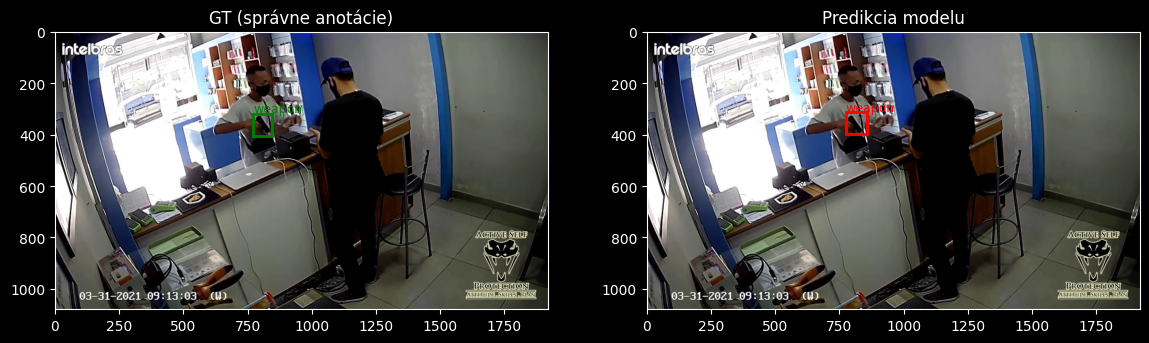

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_comparison(record, idx):
    img = Image.open(record["image_path"]).convert("RGB")
    w, h = img.size

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # GT
    ax1.imshow(img)
    ax1.set_title("GT (správne anotácie)")
    for det in parse_suffix(record["suffix"]):
        y1,x1,y2,x2 = det["bbox"]
        rect = patches.Rectangle((x1*w, y1*h), (x2-x1)*w, (y2-y1)*h,
                                   linewidth=2, edgecolor='green', facecolor='none')
        ax1.add_patch(rect)
        ax1.text(x1*w, y1*h-5, det["label"], color='green', fontsize=9)

    # PRED
    ax2.imshow(img)
    ax2.set_title("Predikcia modelu")
    pred = run_inference(record)
    for det in pred:
        y1,x1,y2,x2 = det["bbox"]
        rect = patches.Rectangle((x1*w, y1*h), (x2-x1)*w, (y2-y1)*h,
                                   linewidth=2, edgecolor='red', facecolor='none')
        ax2.add_patch(rect)
        ax2.text(x1*w, y1*h-5, det["label"], color='red', fontsize=9)

    plt.savefig(f"comparison_{idx}.png", dpi=100, bbox_inches="tight")
    plt.show()

for i in range(3):
    visualize_comparison(val_data[i], i)